In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
import uproot
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [ ]:
RUN = ["3"]
#RUN = ["1","2","3"] #important that it's a string 1) new format to include latest runs 2) to include 'mc_pdg' otherwise it gets dropped

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=False,
    blinded=True,
    load_crt_vars=False,
    enable_cache=True,
)


In [7]:
print(rundata.keys())
#from particle import Particle
print("mc_pz" in rundata["mc"].columns)

dict_keys(['data', 'ext', 'mc', 'nue', 'drt'])
True


In [16]:
import sys
sys.path.append("../../")
from numu_tki import tki_calculators

################################################################################
# Fiducial volume cut is already applied by preselection filter - repeated here
# for completeness

# Definitions from SG's code
'''
FV_X_MIN = 21.5
FV_X_MAX = 234.85
FV_Y_MIN = -95.0
FV_Y_MAX = 95.0
FV_Z_MIN = 21.5
FV_Z_MAX = 966.8
DEAD_Z_MIN = 10000 # SG's code does not cut dead region 
DEAD_Z_MAX = 10000
'''

# Definitions in PeLEE technote and 'selected' variable
# https://github.com/ubneutrinos/searchingfornues/blob/0489ac5457335a553a3bab54ee5d7ba91734adf0/Selection/SelectionTools/CC0piNpSelection_tool.cc#L97-L102
# https://github.com/ubneutrinos/searchingfornues/blob/889002e5ec93b567265c3af8c178172363200490/Selection/SelectionTools/CC0piNpSelection_tool.cc#L415-L420
FV_X_MIN =   10.0
FV_X_MAX =  246.4
FV_Y_MIN = -101.5
FV_Y_MAX =  101.5
FV_Z_MIN =   10.0
FV_Z_MAX =  986.8
DEAD_Z_MIN = 675 # SG's code does not cut dead region 
DEAD_Z_MAX = 775

def sel_reco_vertex_in_FV(reco_nu_vtx_sce_x, reco_nu_vtx_sce_y, reco_nu_vtx_sce_z):
    
    return reco_nu_vtx_sce_x > FV_X_MIN and reco_nu_vtx_sce_x < FV_X_MAX and\
           reco_nu_vtx_sce_y > FV_Y_MIN and reco_nu_vtx_sce_y < FV_Y_MAX and\
           reco_nu_vtx_sce_z > FV_Z_MIN and reco_nu_vtx_sce_z < FV_Z_MAX and\
           not (reco_nu_vtx_sce_z > DEAD_Z_MIN and reco_nu_vtx_sce_z < DEAD_Z_MAX)

################################################################################
# Point located in proton containment volume (PCV) - same as Fiducial volume for now
# Helper function

PCV_X_MIN =   10.0
PCV_X_MAX =  246.4
PCV_Y_MIN = -101.5
PCV_Y_MAX =  101.5
PCV_Z_MIN =   10.0
PCV_Z_MAX = 986.8

def in_proton_containment_vol(x,y,z):
    
    return x > PCV_X_MIN and x < PCV_X_MAX and\
           y > PCV_Y_MIN and y < PCV_Y_MAX and\
           z > PCV_Z_MIN and z < PCV_Z_MAX

################################################################################
# Make vector indicating if tracks/showers are in the containment volume (i.e. checking end is contained)
# Helper function

def is_contained_v(track_end_sce_x_v, track_end_sce_y_v, track_end_sce_z_v):

    contained = []
    for i in range(0,len(track_end_sce_x_v)):
         contained.append(in_proton_containment_vol(track_end_sce_x_v[i], track_end_sce_y_v[i], track_end_sce_z_v[i]))

    return contained

################################################################################
# Check track/shower is contained
# Helper function

def is_contained(Idx, IsContained_v):
    if Idx == -1:
        return False
    return IsContained_v[Idx]

################################################################################
# Returns true if all tracks/showers are contained (i.e. checking generation=2 and start is contained)
# Helper function

def pfp_starts_in_PCV_v(trk_sce_start_x_v, trk_sce_start_y_v, trk_sce_start_z_v):
    
    contained = []
    for i in range(0,len(trk_sce_start_x_v)):
         contained.append(in_proton_containment_vol(trk_sce_start_x_v[i], trk_sce_start_y_v[i], trk_sce_start_z_v[i]))

    return contained

################################################################################
# Returns whether the track/shower passes momentum cuts
# Currently not using upper momentum threshold
# Helper function

proton_p_min = 0.300 #GeV
proton_p_max = 3.0
proton_mass = 0.939
proton_E_min = np.sqrt(proton_p_min**2 + proton_mass**2)
proton_E_max = np.sqrt(proton_p_max**2 + proton_mass**2)

#def pass_mom_cut(RecoMomentum,CUT_LOW,CUT_HIGH):
def pass_mom_cut(RecoMomentum,CUT_LOW):
    if math.isnan(RecoMomentum):
        return False
    
    #return CUT_LOW < RecoMomentum < CUT_HIGH 
    return RecoMomentum > CUT_LOW

################################################################################
# Get indices of reconstructed showers with a starting point within FV

TRACK_SCORE_CUT = 0.5

def reco_showers_v(pfp_generation_v, trk_score_v, pfp_starts_in_PCV_v):
    idx = []
    for i in range(0,len(pfp_generation_v)):
        if pfp_generation_v[i] == 2 and trk_score_v[i] < TRACK_SCORE_CUT and pfp_starts_in_PCV_v[i]:
            idx.append(i)
    
    return idx

################################################################################
# Get number of reconstructed showers with a starting point within FV

def n_reco_showers(reco_showers_v):

    return len(reco_showers_v)

################################################################################
# Get (electron) shower candidate index above threshold

elec_p_min = 0. #GeV
elec_p_max = 1.2 #GeV
elec_mass = 0.511e-3 #GeV
elec_E_min = np.sqrt(elec_p_min**2 + elec_mass**2)
elec_E_max = np.sqrt(elec_p_max**2 + elec_mass**2) # Upper limit currently unused

def reco_elec_candidate_idx(reco_showers_v, shr_energy_cali):

    if len(reco_showers_v) == 1 and shr_energy_cali > elec_E_min:
    #if len(reco_showers_v) == 1 and elec_E_min < shr_energy_cali < elec_E_max:
        return reco_showers_v[0]
    
    return -1

################################################################################
# Find index of the longest track (no pid)

def find_longest_trk_len_idx(pfp_generation_v, trk_len_v):
    
    longest_idx=-1
    longest_len=-1
    for i in range(0,len(pfp_generation_v)):
        if pfp_generation_v[i] == 2 and trk_len_v[i] > longest_len:
            longest_idx = i
            longest_len = trk_len_v[i]

    return longest_idx

# ################################################################################
# # Make a list of the indices of the protons candidates fully contained in the FV

# DEFAULT_PROTON_PID_CUT = 0.02

# def find_proton_candidates(reco_elec_candidate_idx, longest_trk_len_idx, pfp_generation_v, trk_score_v, trk_len_v, trk_llr_pid_score_v, is_contained_v, pfp_starts_in_PCV_v):

#     PID_CUT = 0.015 * trk_len_v[longest_trk_len_idx] + DEFAULT_PROTON_PID_CUT  # for xsec selection as suggested by Elena
#     proton_candidate_idx_v=[]
#     for i in range(0,len(pfp_generation_v)):
#         if pfp_generation_v[i] != 2 or i == reco_elec_candidate_idx or\
#            trk_score_v[i] < TRACK_SCORE_CUT or trk_len_v[i] < 0.0 or\
#            trk_llr_pid_score_v[i] > DEFAULT_PROTON_PID_CUT or\
#            not (is_contained_v[i] and pfp_starts_in_PCV_v[i]): continue
        
#         proton_candidate_idx_v.append(i) 

#     return proton_candidate_idx_v

################################################################################
# Make a list of the indices of the protons candidates fully contained in the FV

DEFAULT_PROTON_PID_CUT = 0.02

def find_proton_candidates(reco_elec_candidate_idx, longest_trk_len_idx, pfp_generation_v, trk_score_v, trk_len_v, trk_llr_pid_score_v, is_contained_v, pfp_starts_in_PCV_v):

    if longest_trk_len_idx == -1:
        PID_CUT = np.nan
    else:
        PID_CUT = 0.015 * trk_len_v[longest_trk_len_idx] + DEFAULT_PROTON_PID_CUT  # for xsec selection as suggested by Elena
    proton_candidate_idx_v=[]
    for i in range(0,len(pfp_generation_v)):
        if pfp_generation_v[i] == 2 and i != reco_elec_candidate_idx and\
           trk_score_v[i] > TRACK_SCORE_CUT and trk_len_v[i] >= 0.0 and\
           trk_llr_pid_score_v[i] < DEFAULT_PROTON_PID_CUT and\
           is_contained_v[i] and pfp_starts_in_PCV_v[i]:
           
           proton_candidate_idx_v.append(i) 

    return proton_candidate_idx_v

################################################################################
# Count the number of proton tracks fully contained in the FV

def n_reco_protons(ProtonCandidateIdx_v):
    return len(ProtonCandidateIdx_v)

################################################################################
# Find index of the longest proton track

def find_leading_proton_candidate(ProtonCandidateIdx_v, trk_len_v):
    
    longest_idx=-1
    longest_len=-1
    for i in range(0,len(trk_len_v)):
        if i in ProtonCandidateIdx_v and trk_len_v[i] > longest_len:
            longest_idx = i
            longest_len = trk_len_v[i]

    return longest_idx

################################################################################
# Get momentum of reconstructed leading proton

MASS_PROTON = 0.939 #0.93827

def get_reco_proton_mom(LeadProtonIdx, trk_energy_proton_v):

    if LeadProtonIdx == -1:
        return np.nan
    ke = trk_energy_proton_v[LeadProtonIdx]
    return np.sqrt(ke**2 + (2*MASS_PROTON*ke))

################################################################################
# Get momentum component of the reconstructed leading proton

def get_reco_proton_mom_comp(LeadProtonIdx, trk_energy_proton_v, trk_dir_v):

    if LeadProtonIdx == -1:
        return np.nan

    ke = trk_energy_proton_v[LeadProtonIdx]
    return np.sqrt(ke**2 + (2*MASS_PROTON*ke)) * trk_dir_v[LeadProtonIdx]

################################################################################
# Get total energy of reconstructed leading proton

def get_reco_proton_E(RecoLeadProtonMomentum):

    return np.sqrt(RecoLeadProtonMomentum**2 + MASS_PROTON**2)

################################################################################
# Get kinetic energy of reconstructed leading proton

def get_reco_proton_KE(LeadProtonIdx, trk_energy_proton_v):

    if LeadProtonIdx == -1:
        return np.nan

    return trk_energy_proton_v[LeadProtonIdx]

################################################################################
# Get momentum of reconstructed protons. Returns a list

def get_reco_proton_mom_v(ProtonCandidateIdx_v, trk_energy_proton_v):

    mom_v = []
    for i in range(0,len(ProtonCandidateIdx_v)):
        ke = trk_energy_proton_v[ProtonCandidateIdx_v[i]]
        mom_v.append(np.sqrt(ke**2 + (2*MASS_PROTON*ke)))

    return mom_v

################################################################################
# Get momentum of reconstructed protons. Returns a list

def get_reco_proton_mom_comp_v(ProtonCandidateIdx_v, trk_energy_proton_v, trk_dir_v):

    mom_v = []
    for i in range(0,len(ProtonCandidateIdx_v)):
        ke = trk_energy_proton_v[ProtonCandidateIdx_v[i]]
        mom_v.append(np.sqrt(ke**2 + (2*MASS_PROTON*ke))*trk_dir_v[ProtonCandidateIdx_v[i]])

    return mom_v

################################################################################
# Get momentum of reconstructed protons. Returns a list

def get_reco_proton_E_v(RecoProtonMomentum_v):

    E_v = []
    for i in range(0,len(RecoProtonMomentum_v)):
        E_v.append(np.sqrt(RecoProtonMomentum_v[i]**2 + MASS_PROTON**2)) 

    return E_v

################################################################################
# Helper function to return the magnitude of a numpy array

def get_magnitude(arr):
    return np.linalg.norm(arr)

In [20]:
def apply_selection_1e1p_tki(up,df):

    # Load the extra branches needed 
    df["trk_dir_x_v"] = up.array("trk_dir_x_v")
    df["trk_dir_y_v"] = up.array("trk_dir_y_v")
    df["trk_dir_z_v"] = up.array("trk_dir_z_v")
    df["trk_energy_proton_v"] = up.array("trk_energy_proton_v")
    # df['shr_energy_cali'] = up.array('shr_energy_cali')
    # df['shr_energy'] = up.array('shr_energy')
    # df['shr_px'] = up.array('shr_px')
    # df['shr_py'] = up.array('shr_py')
    # df['shr_pz'] = up.array('shr_pz')
    df["pfp_generation_v"] = up.array("pfp_generation_v")
    df["trk_score_v"] = up.array("trk_score_v")
    df["trk_len_v"] = up.array("trk_len_v")
    df["trk_llr_pid_score_v"] = up.array("trk_llr_pid_score_v")
    df["trk_sce_start_x_v"] = up.array("trk_sce_start_x_v")
    df["trk_sce_start_y_v"] = up.array("trk_sce_start_y_v")
    df["trk_sce_start_z_v"] = up.array("trk_sce_start_z_v")
    df["trk_sce_end_x_v"] = up.array("trk_sce_end_x_v")
    df["trk_sce_end_y_v"] = up.array("trk_sce_end_y_v")
    df["trk_sce_end_z_v"] = up.array("trk_sce_end_z_v")

    df["InFV_reco"] = df.apply(lambda x: (sel_reco_vertex_in_FV(x["reco_nu_vtx_sce_x"], x["reco_nu_vtx_sce_y"], x["reco_nu_vtx_sce_z"])), axis=1)
    df["PFPStartsInPCV_v"] = df.apply(lambda x: (pfp_starts_in_PCV_v(x["trk_sce_start_x_v"], x["trk_sce_start_y_v"], x["trk_sce_start_z_v"])), axis=1)
    df["IsContained_v"] = df.apply(lambda x: (is_contained_v(x["trk_sce_end_x_v"], x["trk_sce_end_y_v"], x["trk_sce_end_z_v"])),axis=1)

    # Making corrections to the electron energy and momentum variables
    df['RecoElecMomX'] = df['shr_px'] * df['shr_energy_cali'] / df['shr_energy'] / 0.83
    df['RecoElecMomY'] = df['shr_py'] * df['shr_energy_cali'] / df['shr_energy'] / 0.83
    df['RecoElecMomZ'] = df['shr_pz'] * df['shr_energy_cali'] / df['shr_energy'] / 0.83
    df['RecoElecE'] = df['shr_energy_cali'] * 1/0.83
    df["RecoElecKE"] = df["RecoElecE"] - elec_mass
    df['RecoElecModMom'] = np.sqrt((df['RecoElecMomX'])**2 + (df['RecoElecMomY'])**2 + (df['RecoElecMomZ'])**2)

    df["RecoElecPassMomCut"] = df.apply(lambda x: (pass_mom_cut(x["RecoElecModMom"], elec_p_min)),axis=1) 

    df["RecoShowersIndices"] = df.apply(lambda x: (reco_showers_v(x["pfp_generation_v"], x["trk_score_v"], x["PFPStartsInPCV_v"])), axis=1)
    df["RecoElectronCandidateIdx"] = df.apply(lambda x: (reco_elec_candidate_idx(x["RecoShowersIndices"], x["shr_energy_cali"])), axis=1)
    df["n_reco_showers"] = df.apply(lambda x: (n_reco_showers(x["RecoShowersIndices"])), axis=1)
    df["ElectronFullyContained"] = df.apply(lambda x: (is_contained(x["RecoElectronCandidateIdx"], x["IsContained_v"])),axis=1)

    df["longest_trk_len_idx"] = df.apply(lambda x: (find_longest_trk_len_idx(x["pfp_generation_v"], x["trk_len_v"])), axis=1)
    df["RecoProtonIndices"] = df.apply(lambda x: (find_proton_candidates(x["RecoElectronCandidateIdx"], x["longest_trk_len_idx"], x["pfp_generation_v"], x["trk_score_v"], x["trk_len_v"], x["trk_llr_pid_score_v"], x["IsContained_v"], x["PFPStartsInPCV_v"])), axis=1)
    df["RecoLeadProtonCandidateIdx"] = df.apply(lambda x: (find_leading_proton_candidate(x["RecoProtonIndices"], x["trk_len_v"])), axis=1)
    df["n_reco_tracks"] = df.apply(lambda x: (n_reco_protons(x["RecoProtonIndices"])), axis=1)

    df['RecoLeadProtonModMom'] = df.apply(lambda x: (get_reco_proton_mom(x["RecoLeadProtonCandidateIdx"], x["trk_energy_proton_v"])), axis=1)
    df["RecoLeadProtonMomX"] = df.apply(lambda x: (get_reco_proton_mom_comp(x["RecoLeadProtonCandidateIdx"], x["trk_energy_proton_v"], x["trk_dir_x_v"])), axis=1)
    df["RecoLeadProtonMomY"] = df.apply(lambda x: (get_reco_proton_mom_comp(x["RecoLeadProtonCandidateIdx"], x["trk_energy_proton_v"], x["trk_dir_y_v"])), axis=1)
    df["RecoLeadProtonMomZ"] = df.apply(lambda x: (get_reco_proton_mom_comp(x["RecoLeadProtonCandidateIdx"], x["trk_energy_proton_v"], x["trk_dir_z_v"])), axis=1)
    df["RecoLeadProtonE"] = df.apply(lambda x: (get_reco_proton_E(x["RecoLeadProtonModMom"])),axis=1)
    df["RecoLeadProtonKE"] = df.apply(lambda x: (get_reco_proton_KE(x["RecoLeadProtonCandidateIdx"], x["trk_energy_proton_v"])),axis=1)

    df["RecoLeadProtonPassMomCut"] = df.apply(lambda x: (pass_mom_cut(x["RecoLeadProtonModMom"], proton_p_min)),axis=1)
    
    # Set the reco signal definition (no additional cuts)
    #nue_cc0piNp = ((df["RecoElectronCandidateIdx"] != -1) & (df["RecoLeadProtonCandidateIdx"] != -1) & (df["InFV_reco"] == True) & (df["RecoElecPassMomCut"] == True) & (df["RecoLeadProtonPassMomCut"] == True))
    nue_cc0pi1p = ((df["RecoElectronCandidateIdx"] != -1) & (df["RecoLeadProtonCandidateIdx"] != -1) & (df["InFV_reco"] == True) & (df["RecoElecPassMomCut"] == True) & (df["RecoLeadProtonPassMomCut"] == True) & (df["n_reco_tracks"] == 1) & (df["n_reco_showers"] == 1))
    
    # df.loc[nue_cc0piNp, "Signal_1eNp"] = True
    # df.loc[~nue_cc0piNp, "Signal_1eNp"] = False
    
    df.loc[nue_cc0pi1p, "Sel_1e1p"] = True
    df.loc[~nue_cc0pi1p, "Sel_1e1p"] = False


    print("Calc reco TKI variables for leading proton only")

    df["RecoDeltaPT"] = df.apply(lambda x: (tki_calculators.delta_pT(x["RecoElecMomX"],x["RecoElecMomY"],x["RecoElecMomZ"],x["RecoLeadProtonMomX"],x["RecoLeadProtonMomY"],x["RecoLeadProtonMomZ"])),axis=1)
    #df["RecoDeltaPhiT"] = df.apply(lambda x: (tki_calculators.delta_phiT(x["RecoElecMomX"],x["RecoElecMomY"],x["RecoElecMomZ"],x["RecoLeadProtonMomX"],x["RecoLeadProtonMomY"],x["RecoLeadProtonMomZ"])),axis=1)
    df["RecoDeltaAlphaT"] = df.apply(lambda x: (tki_calculators.delta_alphaT(x["RecoElecMomX"],x["RecoElecMomY"],x["RecoElecMomZ"],x["RecoLeadProtonMomX"],x["RecoLeadProtonMomY"],x["RecoLeadProtonMomZ"])),axis=1)
    df['RecoDeltaAlphaT'] = np.degrees(df['RecoDeltaAlphaT'])

    print("Calc reco GKI variables for leading proton only")
    df["RecoPN"] = df.apply(lambda x: (tki_calculators.pn(x["RecoElecE"],x["RecoElecMomX"],x["RecoElecMomY"],x["RecoElecMomZ"],x["RecoLeadProtonE"],x["RecoLeadProtonMomX"],x["RecoLeadProtonMomY"],x["RecoLeadProtonMomZ"])),axis=1)
    df["RecoAlpha3D"] = df.apply(lambda x: (tki_calculators.alpha_3D(x["RecoElecE"],x["RecoElecMomX"],x["RecoElecMomY"],x["RecoElecMomZ"],x["RecoLeadProtonE"],x["RecoLeadProtonMomX"],x["RecoLeadProtonMomY"],x["RecoLeadProtonMomZ"])),axis=1)
    df["RecoAlpha3D"] = np.degrees(df["RecoAlpha3D"])
    #df["RecoPhi3D"] = df.apply(lambda x: (tki_calculators.phi_3D(x["RecoElecE"],x["RecoElecMomX"],x["RecoElecMomY"],x["RecoElecMomZ"],x["RecoLeadProtonE"],x["RecoLeadProtonMomX"],x["RecoLeadProtonMomY"],x["RecoLeadProtonMomZ"])),axis=1)
    df["RecoECal"] = df.apply(lambda x: (tki_calculators.Ecal(x["RecoElecE"],x["RecoLeadProtonE"])),axis=1)
    df["Reco_vec_q"] = df.apply(lambda x: (tki_calculators.vec_q(x["RecoElecE"],x["RecoElecMomX"],x["RecoElecMomY"],x["RecoElecMomZ"],x["RecoLeadProtonE"],x["RecoLeadProtonMomX"],x["RecoLeadProtonMomY"],x["RecoLeadProtonMomZ"])),axis=1)
    df["Reco_mag_q"] = df.apply(lambda x: (get_magnitude(x["Reco_vec_q"])), axis=1)
    df["RecoPL"] = df.apply(lambda x: (tki_calculators.pL(x["RecoElecE"],x["RecoElecMomX"],x["RecoElecMomY"],x["RecoElecMomZ"],x["RecoLeadProtonE"],x["RecoLeadProtonMomX"],x["RecoLeadProtonMomY"],x["RecoLeadProtonMomZ"])),axis=1)
    
    # Drop all of the temporary columns added to the dataframe to save space
    df.drop("pfp_generation_v",inplace=True,axis=1)
    df.drop("trk_score_v",inplace=True,axis=1)
    df.drop("trk_len_v",inplace=True,axis=1)
    df.drop("trk_llr_pid_score_v",inplace=True,axis=1)
    df.drop("trk_sce_start_x_v",inplace=True,axis=1)
    df.drop("trk_sce_start_y_v",inplace=True,axis=1)
    df.drop("trk_sce_start_z_v",inplace=True,axis=1)
    df.drop("trk_sce_end_x_v",inplace=True,axis=1)
    df.drop("trk_sce_end_y_v",inplace=True,axis=1)
    df.drop("trk_sce_end_z_v",inplace=True,axis=1)
    df.drop("trk_energy_proton_v",inplace=True,axis=1)
    df.drop("trk_dir_x_v",inplace=True,axis=1)
    df.drop("trk_dir_y_v",inplace=True,axis=1)
    df.drop("trk_dir_z_v",inplace=True,axis=1)

    return df

In [2]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fold = "nuselection"
tree = "NeutrinoSelectionFilter"
path = "/uboone/data/users/cthorpe/PELEE_2023_Samples/"
RUN1 = "run1/nuepresel/"
RUN2 = "run2/nuepresel/"
RUN3 = "run3/nuepresel/"
RUN4 = "run4/nuepresel/"
RUN5 = "run5/nuepresel/"
fn = "overlay_peleeTuple_uboone_v08_00_00_70_run3_nu.root"

data_path = path + RUN3 + fn

#df = uproot.open('/pnfs/uboone/persistent/users/jdetje/pelee_v08_00_00_70/overlay_peleeTuple_uboone_v08_00_00_70_run3_nu.root')[fold][tree].pandas.df(flatten=False)
#variables = ['mc_pdg', 'mc_E', 'mc_px', 'mc_py', 'mc_pz', 'nu_pdg', 'category', 'true_nu_vtx_x', 'true_nu_vtx_y', 'true_nu_vtx_z']

up = uproot.open('/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_nu.root')[fold][tree]
#df = up.pandas.df(variables, flatten=False)
df = up.pandas.df(flatten=False)

/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/awkward/array/base.py:394: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return cls.numpy.array(value, copy=False)


In [4]:
for col in df.columns:
    print(col)

selected
run
sub
evt
trk_id
shr_id
trk2_id
shr2_id
trk3_id
shr3_id
shr_energy_tot
shr_energy
shr_energy_second
shr_energy_third
shr_energy_tot_cali
shr_energy_cali
shr_energy_second_cali
shr_energy_third_cali
shr_theta
shr_phi
shr_pca_0
shr_pca_1
shr_pca_2
shr_px
shr_py
shr_pz
shr_openangle
shr_tkfit_start_x
shr_tkfit_start_y
shr_tkfit_start_z
shr_tkfit_theta
shr_tkfit_phi
shr_start_x
shr_start_y
shr_start_z
shr_dedx_Y
shr_dedx_V
shr_dedx_U
shr_dedx_Y_cali
shr_dedx_V_cali
shr_dedx_U_cali
shr_tkfit_dedx_Y
shr_tkfit_dedx_V
shr_tkfit_dedx_U
shr_tkfit_dedx_max
shr_tkfit_nhits_Y
shr_tkfit_nhits_V
shr_tkfit_nhits_U
shr_llrpid_dedx_Y
shr_llrpid_dedx_V
shr_llrpid_dedx_U
shr_llrpid_dedx
shr_tkfit_dedx_Y_alt
shr_tkfit_dedx_V_alt
shr_tkfit_dedx_U_alt
shr_tkfit_nhits_Y_alt
shr_tkfit_nhits_V_alt
shr_tkfit_nhits_U_alt
trkfit
shr_tkfit_npoints
shr_tkfit_npointsvalid
shr_trkfitmedangle
shrmoliereavg
shrmoliererms
shr1shr2moliereavg
shr1shr2moliererms
shr1trk1moliereavg
shr1trk1moliererms
shr1trk2molie

In [14]:
df.loc[:,("shr_llrpid_dedx", "shr_llr_pid_score_v", "trk_trunk_dEdx_u_v", "trk_trunk_dEdx_v_v", "trk_trunk_dEdx_y_v", "trk_trunk_rr_dEdx_u_v", "trk_trunk_rr_dEdx_v_v", "trk_trunk_rr_dEdx_y_v")].head(20)

,shr_llrpid_dedx,shr_llr_pid_score_v,trk_trunk_dEdx_u_v,trk_trunk_dEdx_v_v,trk_trunk_dEdx_y_v,trk_trunk_rr_dEdx_u_v,trk_trunk_rr_dEdx_v_v,trk_trunk_rr_dEdx_y_v
entry,,,,,,,,
0,-3.568332e-02,"[0.84179693, 0.14742203, -0.30837053, -0.84334...","[1.891933, 2.4975762, 1.7908529, 2.5101714, -3...","[2.019021, 0.82559663, 4.179372, 950.267, 3.95...","[2.1169596, 2.4381227, 0.4394421, 2.553928, 4....","[1.8775953, 2.4980922, 1.7729183, 3.323068, 4....","[1.976019, 0.88998765, 2.5965197, 248.34766, 4...","[1.9900745, 2.5386431, 0.59567815, 3.0026577, ..."
1,-3.402823e+38,"[0.0, -0.4385717, -0.8413997, -0.69630945, -0....","[1.5383968, 4.533413, 3.7122993, -3.4028235e+3...","[1.5981016, 0.33132127, 4.2854466, -3.4028235e...","[5.912517, 2.5814807, 5.2084146, -3.4028235e+3...","[1.336257, 3.1455011, 4.479208, 9.119225, 0.68...","[1.5535651, 0.3215742, 5.0323076, 5.648741, -3...","[4.8492727, 2.5264235, 5.2829413, 13.890084, 9..."
2,8.090255e-02,"[0.5593027, 0.0, 0.0, -3.4028235e+38, -0.40147...","[2.5801504, -3.4028235e+38, 1.498434, -3.40282...","[38.703854, 6.6078773, -3.4028235e+38, -3.4028...","[2.1362357, 2.1475108, -3.4028235e+38, -3.4028...","[1.9297144, 7.249123, 1.566661, -3.4028235e+38...","[16.17813, -3.4028235e+38, -3.4028235e+38, -3....","[2.0793424, 2.2682762, 0.39606377, -3.4028235e..."
3,-3.402823e+38,"[0.0, -0.7893662]","[0.24470419, 2.9893413]","[29.16753, 0.32350662]","[2.4138863, 6.370572]","[0.44392017, 1.7488184]","[20.183321, 1.8121338]","[2.3876016, 5.2598805]"
4,6.689695e-02,"[0.56000197, -0.46202946, -0.84381294]","[2.9107368, 0.4852378, 6.0891414]","[3.247802, 2.0177422, -3.4028235e+38]","[3.5469575, -3.4028235e+38, 13.305182]","[3.3123915, 0.70393145, 7.2465463]","[3.331646, 2.2354925, 5.962904]","[3.0043018, 3.6501644, 8.847171]"
5,-5.721760e-02,"[0.9262816, -0.48710892]","[2.5705705, -3.4028235e+38]","[0.18644245, -3.4028235e+38]","[1.8478818, 4.042985]","[2.4344416, 2.1377416]","[0.18746679, 8.508748]","[1.9617779, 4.319575]"
6,2.747850e-02,"[0.3826057, 0.61588734, -3.4028235e+38]","[4.5471025, -3.4028235e+38, -3.4028235e+38]","[5.9219747, -3.4028235e+38, -3.4028235e+38]","[6.1444936, -3.4028235e+38, -3.4028235e+38]","[5.0976357, 2.0346663, 11.253121]","[2.870911, 2.9995172, 9.539984]","[18.852278, 1.7991855, -3.4028235e+38]"
7,6.471142e-02,[0.5617037],[-3.4028235e+38],[4.376526],[4.8726687],[0.49674004],[3.5517173],[3.263785]
8,9.185785e-03,"[0.09123447, 0.07709749]","[0.8608328, -3.4028235e+38]","[0.6415551, 2.2423882]","[5.093401, -3.4028235e+38]","[1.1612611, -3.4028235e+38]","[0.53026193, 2.564995]","[3.4802277, 3.409007]"


In [22]:
run3mc = apply_selection_1e1p_tki(up,df)

Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only


In [23]:
run3mc.loc[:, ('Sel_1e1p', 'RecoPN', 'RecoAlpha3D', 'RecoECal', 'Reco_mag_q', 'RecoPL')].head(20)

,Sel_1e1p,RecoPN,RecoAlpha3D,RecoECal,Reco_mag_q,RecoPL
entry,,,,,,
0,False,0.448204,73.444829,0.368842,0.403493,0.089851
1,False,0.966370,147.749461,0.678532,0.402098,0.587060
2,False,NaN,NaN,NaN,NaN,NaN
3,False,NaN,NaN,NaN,NaN,NaN
4,True,0.387405,83.143061,0.380427,0.377733,0.075668
5,False,NaN,NaN,NaN,NaN,NaN
6,True,0.094168,65.046254,1.012080,0.413217,0.030331
7,False,NaN,NaN,NaN,NaN,NaN
8,False,NaN,NaN,NaN,NaN,NaN


(array([1.1089e+04, 2.6870e+03, 2.9500e+02, 6.9000e+01, 1.9000e+01,
        9.0000e+00, 5.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00]),
 array([1.02807986e-06, 3.26473466e-01, 6.52945905e-01, 9.79418343e-01,
        1.30589078e+00, 1.63236322e+00, 1.95883566e+00, 2.28530810e+00,
        2.61178054e+00, 2.93825297e+00, 3.26472541e+00]),
 <BarContainer object of 10 artists>)

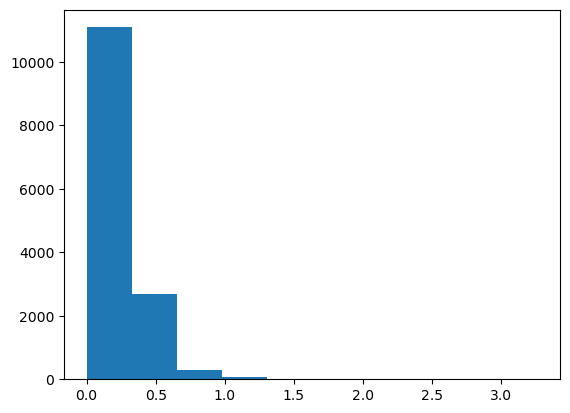

In [27]:
plt.hist(run3mc['RecoPL'], 10)

In [9]:
is_sig = run3mc['Signal_1e1p'] == True
all_sig = run3mc.loc[is_sig]

top_sig = run3mc['category_1e1p_tki'] == 12
all_top_sig = run3mc.loc[top_sig]

test_sig = run3mc['test'] == 12
all_test_sig = run3mc.loc[test_sig]

print('Signal_1e1p:', len(all_sig))
print('category_1e1p_tki:', len(all_top_sig))
print('test:', len(all_test_sig))
print(len(run3mc))

Signal_1e1p: 485
category_1e1p_tki: 485
test: 485
1047989


In [15]:
all_mc = pd.concat([df for k, df in rundata.items() if k!='data' or k!='ext'])

In [ ]:
from microfit import selections as sel

#print(sel.selection_categories)

selection = "OnePL"
preselection = "OneP"
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
#print(query)

all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])
#is_sig = all_mc['category_1e1p_tki'] == 12
is_sig = all_mc['Signal_1e1p'] == True
all_sig = all_mc.loc[is_sig]
sel_sig = all_sig.query(query, engine='python')

print(len(all_sig))
print()

all_mc.loc[all_mc['category_1e1p_tki'] == 6].head()
print(len(all_mc))
print(len(all_mc.loc[all_mc['category_1e1p_tki'] == 6]))
plt.hist(all_mc['category_1e1p_tki'], 31)